In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
trainpath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/train.csv'
testpath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/test.csv'
samplepath='/content/drive/MyDrive/Colab Notebooks/Kaggle/Credit Card Fraud Analysis/元データ/sample_submission.csv'

train=pd.read_csv(trainpath)
test=pd.read_csv(testpath)
sample=pd.read_csv(samplepath)
sample

,Idx,Reducted Cost
0,0,1223956.75


Credit Card Fraud Analysis  
　概要（抜粋）  
　　銀行のモデルを分析し、何が問題なのか、そしてモデルを微調整することで顧客を  
　失わずに済むかどうかを探ってほしいと考えています。なぜなら、顧客を失うことは  
　お金の損失につながるからです。不正行為が発生した場合、損失は不正に発生した金  
　額のみですが、顧客が離れれば、将来の取引と顧客の信頼の両方を失うことになり、  
　その  損失はさらに大きくなります。  
  
機能要求    
　　解約リスクや確認コストの観点から指標を４段階評価  
　　・取引停止    
　　・追加認証  
　　・職員によるモニタリング確認  
　　・メール確認  


下処理　検討後

1. Vカラム以外の処理検討（Time)  
   (1)時間変換（24時間を超える場合は24時間を減算)   
   (2)20分区切り、20分未満の時間を切捨て  

2. Vカラム以外の処理検討(Amount)  
  前述のとおり、V1～V28との相関が金額帯・時間帯で変わるためビン分けを実施。  
分け方は3分類（①100未満②100以上～500未満③500以上）

3. Vカラム以外の処理検討(Idx)  
   重複ないため処理不要

4. Vカラムの処理  
   対数スケール（y軸)ヒストグラムより、標準化されており処理不要

In [4]:
#1-1　下準備　Vカラム以外の処理検討(Time)

# 1. 時間変換関数の定義
def preprocess_time(df):
    # (1) 24時間変換（24時間を超える場合は24時間を減算）
    # 86400秒 = 24時間
    df['Time_24h'] = df['Time'] % 86400

    # (2) 20分区切り（20分未満を切り捨て）
    # 20分 = 1200秒
    # // は整数除算（切り捨て）
    df['20min'] = (df['Time_24h'] // 1200).astype(int)

    return df

# 2. train と test の両方に適用
train = preprocess_time(train)
test = preprocess_time(test)

# 3. 学習データ(train)での分布確認
time_summary = train.groupby('20min').agg(
    Count=('Class', 'count'),
    Fraud_Count=('Class', 'sum')
).reset_index()

print("🚀 === 学習データ(Train)の20minスロット分布（一部） ===")
print("-" * 50)
print(time_summary.head(24).to_string(index=False))

🚀 === 学習データ(Train)の20minスロット分布（一部） ===
--------------------------------------------------
 20min  Count  Fraud_Count
     0   2100            1
     1   1857            3
     2   1413            0
     3   1425            3
     4    814            5
     5    689            1
     6    802           26
     7    735            9
     8    769            4
     9   1410            4
    10    501            4
    11    498            5
    12    869            3
    13    340            7
    14    356            6
    15    600            4
    16    848            3
    17    648            3
    18    809            0
    19    969            3
    20   1049            5
    21   1339            3
    22   1851            9
    23   1855            7


In [5]:
#1-2　下準備　Vカラム以外の処理検討(Amount)

# 1. ラベル化の関数定義（Trainで決めた閾値 100, 500 を使用）
def label_amount(amt):
    if amt < 100:
        return 0
    elif amt < 500:
        return 1
    else:
        return 2  # Over $500

# 2. 処理（ラベル化）
train['Amount_Bin'] = train['Amount'].apply(label_amount)
test['Amount_Bin'] = test['Amount'].apply(label_amount)

# 3. 集計・表示
bin_names = {0: 'Under $100', 1: '$100 - $500', 2: 'Over $500'}
train_summary = train.groupby('Amount_Bin').agg(
    Count=('Amount', 'count'),
    Fraud_Count=('Class', 'sum'),
    Mean_Amount=('Amount', 'mean')
).reset_index()

train_summary['Segment'] = train_summary['Amount_Bin'].map(bin_names)
train_summary['Fraud_Ratio(%)'] = (train_summary['Fraud_Count'] / train_summary['Count']) * 100

cols = ['Amount_Bin', 'Segment', 'Count', 'Fraud_Count', 'Fraud_Ratio(%)']

print("=== 学習データ（Train）のセグメント分布確認 ===")
print("-" * 65)
print(train_summary[cols].to_string(index=False))

=== 学習データ（Train）のセグメント分布確認 ===
-----------------------------------------------------------------
 Amount_Bin     Segment  Count  Fraud_Count  Fraud_Ratio(%)
          0  Under $100 159206          263        0.165195
          1 $100 - $500  33509           68        0.202931
          2   Over $500   6649           29        0.436156


学習モデル作成において
(EDA結果より)
1.   金額帯によって相関が異なることから低中高に分けてモデル作成。
2.   高金額帯は金額重み付け、中金額帯は時間で重み付けを行う。


3.   低金額帯において金額重み付けをすると１ドル等を拾わなくなるリスクが見込まれるため重み付け1.0


3.   モデルはXGB　スケールウェイト（正常/不正）
4.   交差検証あり、スモートなし(過学習防止)




In [6]:
#2-1　モデル前処理　金額層別にデータ分類
train_low  = train[train['Amount_Bin'] == 0].copy()
train_mid  = train[train['Amount_Bin'] == 1].copy()
train_high = train[train['Amount_Bin'] == 2].copy()

test_low   = test[test['Amount_Bin'] == 0].copy()
test_mid   = test[test['Amount_Bin'] == 1].copy()
test_high  = test[test['Amount_Bin'] == 2].copy()


features = [f'V{i}' for i in range(1, 29)] + ['20min', 'Amount']
#学習モデルをAmount_Binで分けたため特徴量としては不要


# --- Low Segment (<$100) ---
X_train_low = train_low[features]
y_train_low = train_low['Class']
X_test_low  = test_low[features]

# --- Mid Segment ($100-$500) ---
X_train_mid = train_mid[features]
y_train_mid = train_mid['Class']
X_test_mid  = test_mid[features]

# --- High Segment (>$500) ---
X_train_high = train_high[features]
y_train_high = train_high['Class']
X_test_high  = test_high[features]

In [7]:
#2-2　モデル前処理　重み付け

# --- 1. Low Segment (<$100)---
weights_low = np.ones(len(X_train_low))

# --- 2. Mid Segment ($100-$500): 「時間」---
slot_probs = train_mid.groupby('20min')['Class'].mean().to_dict()
time_factor = train_mid['20min'].map(slot_probs).fillna(0.001).values  # 不正が1件もないスロットに最小値 0.001 を設定
time_weight = time_factor / time_factor.mean()
a=2
weights_mid = (train_mid['Class'] * a + 1) * time_weight

# --- 3. High Segment (>$500): 「金額」---
b=5
weights_high = (train_high['Amount'] / train_high['Amount'].median()) * (train_high['Class'] * b + 1)

# --- 確認表示 ---
print("=== 各セグメントの重み（sample_weight）設定完了 ===")
print(f"Low  | 形状: {weights_low.shape}  | 設定: 一律 1.0 (全件平等)")
print(f"Mid  | 形状: {weights_mid.shape}  | 設定: 20minスロット別の不正密度 (最大重み: {weights_mid.max():.4f})")
print(f"High | 形状: {weights_high.shape} | 設定: 金額(Amount)比例 (最大重み: {weights_high.max():.2f})")

=== 各セグメントの重み（sample_weight）設定完了 ===
Low  | 形状: (159206,)  | 設定: 一律 1.0 (全件平等)
Mid  | 形状: (33509,)  | 設定: 20minスロット別の不正密度 (最大重み: 71.0740)
High | 形状: (6649,) | 設定: 金額(Amount)比例 (最大重み: 33.32)


In [8]:
#3-1　学習モデル　高金額帯(500以上)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score, f1_score, recall_score, precision_score
import numpy as np

# 1. パラメータ設定
ratio = 6649 / 29
threshold = 0.01
model_high = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    scale_pos_weight=ratio, random_state=42,
    use_label_encoder=False, eval_metric='aucpr',
    colsample_bytree=0.8
)

# 2. 5-Fold 交差検証
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#3. 指標格納用
results = {
    'pr_auc': [], 'w_recall': [],
    'p1': [], 'r1': [], 'f1_1': [],
    'p0': [], 'r0': [], 'f1_0': [],
    'amt_saved': [], 'amt_missed': []
}

print(f"=== High層：5-Fold 交差検証 開始 (Threshold: {threshold}) ===\n")

for i, (train_idx, val_idx) in enumerate(skf.split(X_train_high, y_train_high)):
    X_t, X_v = X_train_high.iloc[train_idx], X_train_high.iloc[val_idx]
    y_t, y_v = y_train_high.iloc[train_idx], y_train_high.iloc[val_idx]
    w_t = weights_high.iloc[train_idx]

    model_high.fit(X_t, y_t, sample_weight=w_t)

    y_prob = model_high.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    #4. 金額集計
    v_amounts = train_high.loc[y_v.index, 'Amount']
    fraud_mask = (y_v == 1)
    amt_saved = v_amounts[fraud_mask & (y_pred == 1)].sum()
    amt_missed = v_amounts[fraud_mask & (y_pred == 0)].sum()
    total_fraud_amt = amt_saved + amt_missed

    #5. 各種スコア計算
    results['pr_auc'].append(average_precision_score(y_v, y_prob))
    results['w_recall'].append(amt_saved / total_fraud_amt if total_fraud_amt > 0 else 0)

    #6. クラス1 (不正)
    results['p1'].append(precision_score(y_v, y_pred, pos_label=1, zero_division=0))
    results['r1'].append(recall_score(y_v, y_pred, pos_label=1, zero_division=0))
    results['f1_1'].append(f1_score(y_v, y_pred, pos_label=1, zero_division=0))

    #7. クラス0 (正常)
    results['p0'].append(precision_score(y_v, y_pred, pos_label=0, zero_division=0))
    results['r0'].append(recall_score(y_v, y_pred, pos_label=0, zero_division=0))
    results['f1_0'].append(f1_score(y_v, y_pred, pos_label=0, zero_division=0))

    results['amt_saved'].append(amt_saved)
    results['amt_missed'].append(amt_missed)

    print(f"Fold {i+1}: 検知 ${amt_saved:,.0f} / 見逃し ${amt_missed:,.0f} (PR-AUC: {results['pr_auc'][-1]:.4f})")

#8. --- 結果表示 ---
print("\n" + "="*60)
print(f" 【High層 CV最終結果 (5-Fold平均)】")
print(f" 平均検知額: ${np.mean(results['amt_saved']):,.0f} | 平均見逃し額: ${np.mean(results['amt_missed']):,.0f}")
print(f" 金額荷重Recall: {np.mean(results['w_recall']):.4f} | PR-AUC: {np.mean(results['pr_auc']):.4f}")
print("-" * 60)
print(f"🟥 クラス1(不正) | Precision: {np.mean(results['p1']):.4f} | Recall: {np.mean(results['r1']):.4f} | F1: {np.mean(results['f1_1']):.4f}")
print(f"🟩 クラス0(正常) | Precision: {np.mean(results['p0']):.4f} | Recall: {np.mean(results['r0']):.4f} | F1: {np.mean(results['f1_0']):.4f}")
print("="*60)

#9. 全データで最終学習
model_high.fit(X_train_high, y_train_high, sample_weight=weights_high);

=== High層：5-Fold 交差検証 開始 (Threshold: 0.01) ===

Fold 1: 検知 $2,985 / 見逃し $2,903 (PR-AUC: 0.6744)
Fold 2: 検知 $5,036 / 見逃し $0 (PR-AUC: 0.8529)
Fold 3: 検知 $3,915 / 見逃し $1,984 (PR-AUC: 0.3677)
Fold 4: 検知 $3,627 / 見逃し $1,078 (PR-AUC: 0.6706)
Fold 5: 検知 $4,893 / 見逃し $723 (PR-AUC: 0.8014)

 【High層 CV最終結果 (5-Fold平均)】
 平均検知額: $4,091 | 平均見逃し額: $1,338
 金額荷重Recall: 0.7625 | PR-AUC: 0.6734
------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.0768 | Recall: 0.7267 | F1: 0.1351
🟩 クラス0(正常) | Precision: 0.9987 | Recall: 0.9565 | F1: 0.9771


高金額帯では検知数自体が少なくなり、誤検知の負担が小さくなること及び１件あたりの被害総額が大きくなることから不正のPrecisionの低さよりもRecallと金額加重Recallを重視して閾値を最適化した。

In [9]:
#3-2　学習モデル　中金額帯(100以上500未満)

# --- 1. モデル定義 ---
ratio_mid = len(train_mid[train_mid['Class']==0]) / len(train_mid[train_mid['Class']==1])
threshold = 0.95

model_mid = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    scale_pos_weight=ratio_mid, random_state=42,
    use_label_encoder=False, eval_metric='aucpr',
    colsample_bytree=0.8
)

# --- 2. 5-Fold 交差検証 ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
res = {'pr_auc': [], 'w_rec': [], 'p1': [], 'r1': [], 'p0': [], 'r0': [], 'saved': [], 'missed': []}

print(f" === Mid層：10-Fold 交差検証 開始 (b={b},) ===\n")

for i, (train_idx, val_idx) in enumerate(skf.split(X_train_mid, y_train_mid)):
    X_t, X_v = X_train_mid.iloc[train_idx], X_train_mid.iloc[val_idx]
    y_t, y_v = y_train_mid.iloc[train_idx], y_train_mid.iloc[val_idx]
    w_t = weights_mid.iloc[train_idx]

    model_mid.fit(X_t, y_t, sample_weight=w_t)
    y_prob = model_mid.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    #3. 金額集計
    amt_v = train_mid.loc[y_v.index, 'Amount']
    s = amt_v[(y_v == 1) & (y_pred == 1)].sum()
    m = amt_v[(y_v == 1) & (y_pred == 0)].sum()

    res['pr_auc'].append(average_precision_score(y_v, y_prob))
    res['w_rec'].append(s / (s + m) if (s + m) > 0 else 0)
    res['p1'].append(precision_score(y_v, y_pred, pos_label=1, zero_division=0))
    res['r1'].append(recall_score(y_v, y_pred, pos_label=1, zero_division=0))
    res['p0'].append(precision_score(y_v, y_pred, pos_label=0, zero_division=0))
    res['r0'].append(recall_score(y_v, y_pred, pos_label=0, zero_division=0))
    res['saved'].append(s); res['missed'].append(m)

    print(f"Fold {i+1}: 検知 ${s:,.0f} / 見逃し ${m:,.0f} (PR-AUC: {res['pr_auc'][-1]:.4f})")

# --- 4. 結果表示 (フォーマット統一版) ---
from sklearn.metrics import f1_score

mean_p1 = np.mean(res['p1'])
mean_r1 = np.mean(res['r1'])
f1_1 = 2 * (mean_p1 * mean_r1) / (mean_p1 + mean_r1) if (mean_p1 + mean_r1) > 0 else 0

mean_p0 = np.mean(res['p0'])
mean_r0 = np.mean(res['r0'])
f1_0 = 2 * (mean_p0 * mean_r0) / (mean_p0 + mean_r0) if (mean_p0 + mean_r0) > 0 else 0

print("\n" + "="*60)
print(f" 【Mid層 CV最終結果 (10-Fold平均)】")
print(f" 平均検知額: ${np.mean(res['saved']):,.0f} | 平均見逃し額: ${np.mean(res['missed']):,.0f}")
print(f" 金額荷重Recall: {np.mean(res['w_rec']):.4f} | PR-AUC: {np.mean(res['pr_auc']):.4f}")
print("-" * 60)
print(f"🟥 クラス1(不正) | Precision: {mean_p1:.4f} | Recall: {mean_r1:.4f} | F1: {f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {mean_p0:.4f} | Recall: {mean_r0:.4f} | F1: {f1_0:.4f}")
print("="*60)

 === Mid層：10-Fold 交差検証 開始 (b=5,) ===

Fold 1: 検知 $2,383 / 見逃し $292 (PR-AUC: 0.8168)
Fold 2: 検知 $2,951 / 見逃し $0 (PR-AUC: 0.8582)
Fold 3: 検知 $3,032 / 見逃し $358 (PR-AUC: 0.9290)
Fold 4: 検知 $2,720 / 見逃し $750 (PR-AUC: 0.7864)
Fold 5: 検知 $1,647 / 見逃し $1,205 (PR-AUC: 0.7904)

 【Mid層 CV最終結果 (10-Fold平均)】
 平均検知額: $2,546 | 平均見逃し額: $521
 金額荷重Recall: 0.8293 | PR-AUC: 0.8362
------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.9442 | Recall: 0.8505 | F1: 0.8949
🟩 クラス0(正常) | Precision: 0.9997 | Recall: 0.9999 | F1: 0.9998


中金額帯以下は検知数が多くなることからF1スコアを重視して閾値を最適化。  
中金額帯は時間帯で重み付けした結果、閾値0.95でクラス１とクラス０のF1値を良好な値となった。

In [10]:
#3-3　学習モデル　低金額帯(100未満)

# --- 1. モデル定義 ---
ratio_low = len(train_low[train_low['Class']==0]) / len(train_low[train_low['Class']==1])
threshold_low = 0.95

model_low = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    scale_pos_weight=ratio_low, random_state=42,
    use_label_encoder=False, eval_metric='aucpr',
    colsample_bytree=0.8
)

# --- 2. 10-Fold 交差検証 ---
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
res = {'pr_auc': [], 'w_rec': [], 'p1': [], 'r1': [], 'p0': [], 'r0': [], 'saved': [], 'missed': []}

print(f" === Low層：交差検証開始 (Threshold: {threshold_low}) ===\n")

for i, (train_idx, val_idx) in enumerate(skf.split(X_train_low, y_train_low)):
    X_t, X_v = X_train_low.iloc[train_idx], X_train_low.iloc[val_idx]
    y_t, y_v = y_train_low.iloc[train_idx], y_train_low.iloc[val_idx]
    w_t = weights_low[train_idx]

    model_low.fit(X_t, y_t, sample_weight=w_t)
    y_prob = model_low.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= threshold_low).astype(int)

    #3. 金額集計
    amt_v = train_low.loc[y_v.index, 'Amount']
    s = amt_v[(y_v == 1) & (y_pred == 1)].sum()
    m = amt_v[(y_v == 1) & (y_pred == 0)].sum()

    res['pr_auc'].append(average_precision_score(y_v, y_prob))
    res['w_rec'].append(s / (s + m) if (s + m) > 0 else 0)
    res['p1'].append(precision_score(y_v, y_pred, pos_label=1, zero_division=0))
    res['r1'].append(recall_score(y_v, y_pred, pos_label=1, zero_division=0))
    res['p0'].append(precision_score(y_v, y_pred, pos_label=0, zero_division=0))
    res['r0'].append(recall_score(y_v, y_pred, pos_label=0, zero_division=0))
    res['saved'].append(s); res['missed'].append(m)

    print(f"Fold {i+1}完了: PR-AUC={res['pr_auc'][-1]:.4f}")

# --- 4. 結果表示 (フォーマット統一版) ---

# F1スコアの平均を計算（Pre/Recの平均から算出）
mean_p1 = np.mean(res['p1'])
mean_r1 = np.mean(res['r1'])
f1_1 = 2 * (mean_p1 * mean_r1) / (mean_p1 + mean_r1) if (mean_p1 + mean_r1) > 0 else 0

mean_p0 = np.mean(res['p0'])
mean_r0 = np.mean(res['r0'])
f1_0 = 2 * (mean_p0 * mean_r0) / (mean_p0 + mean_r0) if (mean_p0 + mean_r0) > 0 else 0

print("\n" + "="*60)
print(f" 【Low層 CV最終結果 (10-Fold平均)】")
print(f" 平均検知額: ${np.mean(res['saved']):,.0f} | 平均見逃し額: ${np.mean(res['missed']):,.0f}")
print(f" 金額荷重Recall: {np.mean(res['w_rec']):.4f} | PR-AUC: {np.mean(res['pr_auc']):.4f}")
print("-" * 60)
print(f"🟥 クラス1(不正) | Precision: {mean_p1:.4f} | Recall: {mean_r1:.4f} | F1: {f1_1:.4f}")
print(f"🟩 クラス0(正常) | Precision: {mean_p0:.4f} | Recall: {mean_r0:.4f} | F1: {f1_0:.4f}")
print("="*60)

 === Low層：交差検証開始 (Threshold: 0.95) ===

Fold 1完了: PR-AUC=0.7896
Fold 2完了: PR-AUC=0.8048
Fold 3完了: PR-AUC=0.9023
Fold 4完了: PR-AUC=0.8694
Fold 5完了: PR-AUC=0.7801
Fold 6完了: PR-AUC=0.8012
Fold 7完了: PR-AUC=0.7917
Fold 8完了: PR-AUC=0.8351
Fold 9完了: PR-AUC=0.8818
Fold 10完了: PR-AUC=0.8693

 【Low層 CV最終結果 (10-Fold平均)】
 平均検知額: $463 | 平均見逃し額: $49
 金額荷重Recall: 0.9046 | PR-AUC: 0.8325
------------------------------------------------------------
🟥 クラス1(不正) | Precision: 0.8562 | Recall: 0.8061 | F1: 0.8304
🟩 クラス0(正常) | Precision: 0.9997 | Recall: 0.9998 | F1: 0.9997


低価格帯においては取引件数の多さからクラス0のPrecision及びF1を重視して閾値を模索し、0.95とした上で良好な結果を得た。

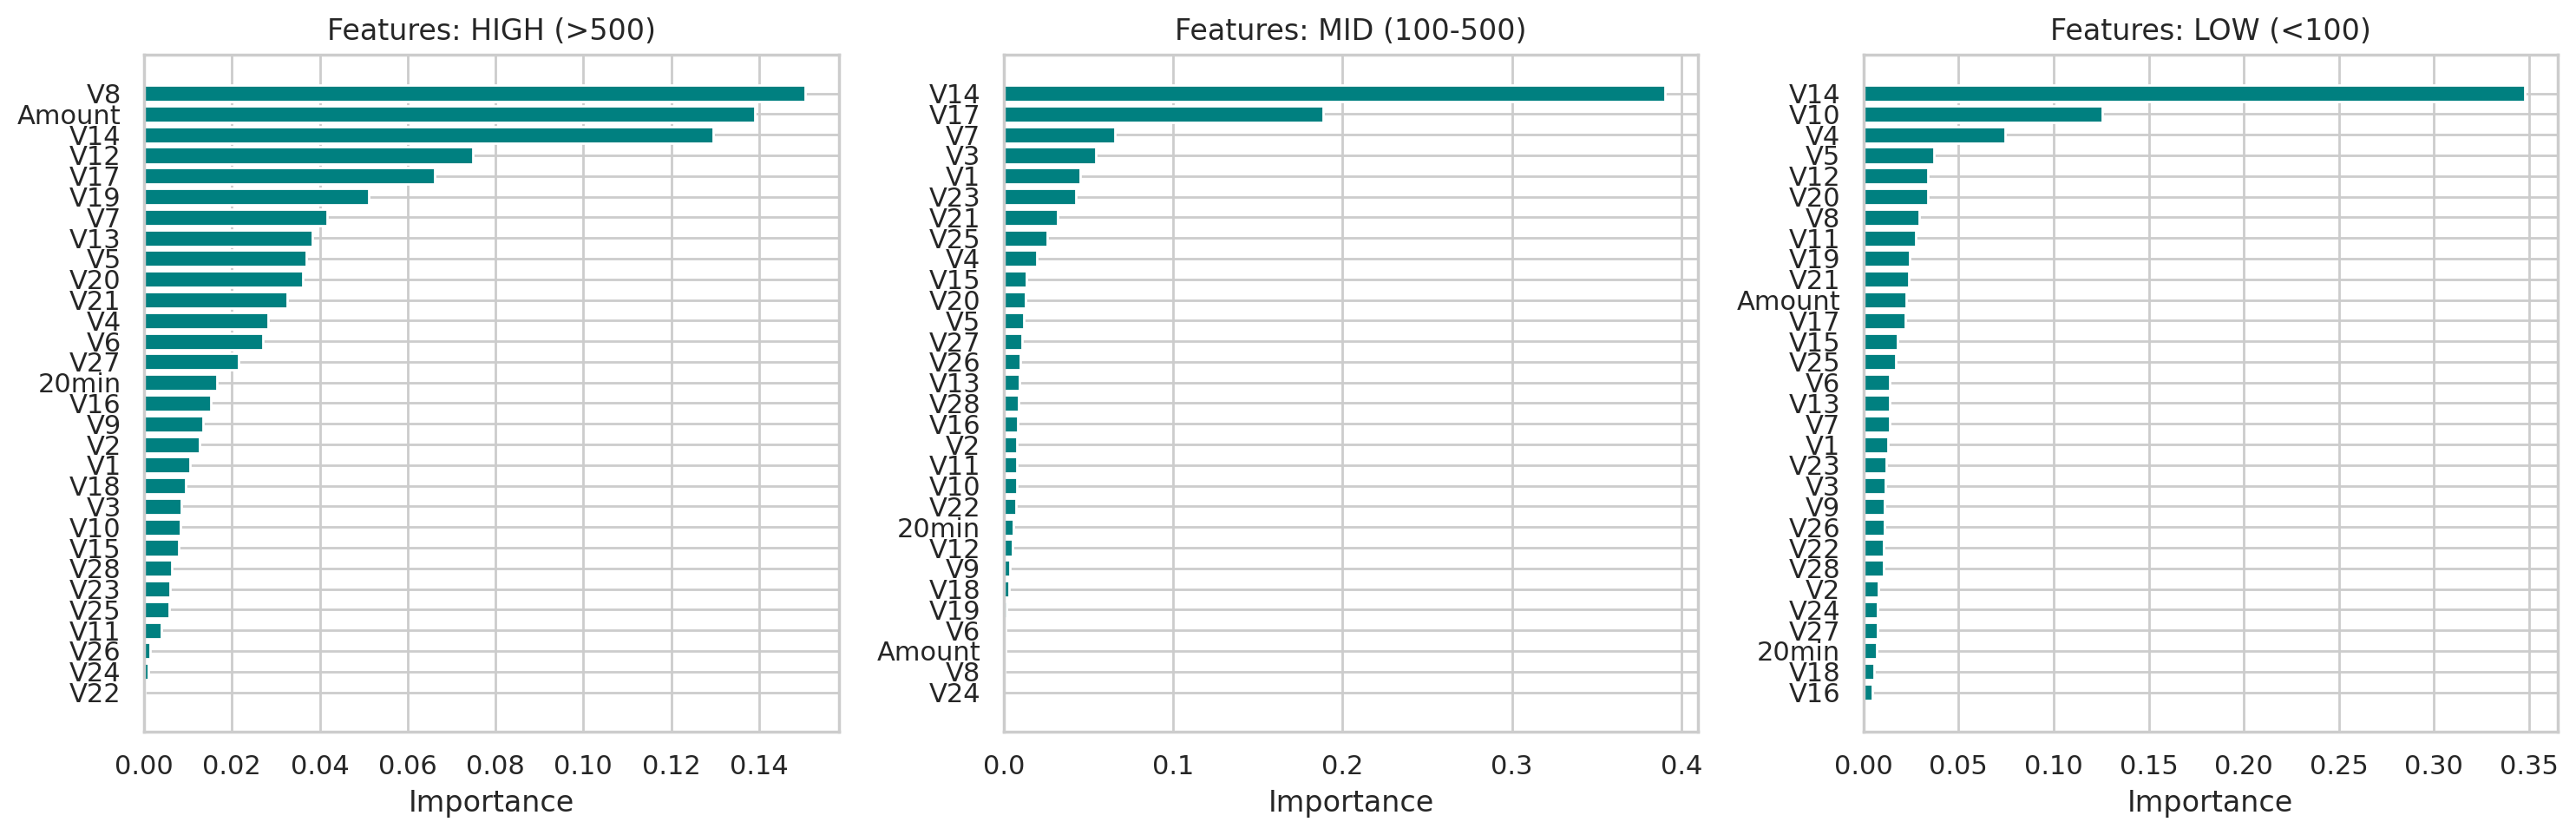

In [11]:
#3-4　学習モデル　各層特徴量の寄与度

models = [
    (model_high, X_train_high, "HIGH (>500)"),
    (model_mid,  X_train_mid,  "MID (100-500)"),
    (model_low,  X_train_low,  "LOW (<100)")
]

plt.figure(figsize=(15, 5))

for i, (model, X_data, name) in enumerate(models):
    # 寄与度の取得
    importances = model.feature_importances_
    # インデックス取得
    indices = np.argsort(importances)[-30:]

    plt.subplot(1, 3, i+1)
    plt.title(f'Features: {name}')
    plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [X_data.columns[j] for j in indices])
    plt.xlabel('Importance')

plt.tight_layout()
plt.show()

【V14の支配的影響とセグメント特性】

・低・中金額帯: V14 が突出した寄与度（低：0.35、中：0.40）を示し、不正検知の主軸となっている。なお、中金額帯の時間(20min)は低調であり、高金額の方が高い結果となった。

・高金額帯: V14 は依然として重要（寄与度3位：約0.13ではあるものの、その支配力は低下している。

【高金額帯における特異性】

・高金額帯においては、V8 や Amount（取引金額）の寄与度が V14 を上回り、上位を独占している。これは、高額不正がV14以上に、「取引規模」と「高額決済特有の異常挙動（V8）」に強く紐付いていることを示唆している。

【層別アプローチの妥当性】

・各金額帯の寄与度上位5項目を比較した際、全層共通してランクインしているのは V14のみであった。この結果は、全金額を一括で学習させた場合、件数の多い低・中金額帯のパターンにモデルが引きずられ、高金額の重要なシグナル（V8等）を見逃すリスクがあったことを裏付けている。

In [12]:
#4-1　テストデータへの適用

# 各層のモデルを定義（これまでのベスト設定）
model_high = XGBClassifier( n_estimators=200, learning_rate=0.05, max_depth=3,
                           scale_pos_weight=ratio, random_state=42,use_label_encoder=False,
                            eval_metric='aucpr',colsample_bytree=0.8)
model_mid  = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                           scale_pos_weight=ratio_mid, random_state=42,use_label_encoder=False,
                           eval_metric='aucpr',colsample_bytree=0.8)
model_low  = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                           scale_pos_weight=ratio_low, random_state=42,use_label_encoder=False,
                           eval_metric='aucpr',colsample_bytree=0.8)

# 学習実行
model_high.fit(X_train_high, y_train_high, sample_weight=weights_high)
model_mid.fit(X_train_mid, y_train_mid, sample_weight=weights_mid)
model_low.fit(X_train_low, y_train_low, sample_weight=weights_low)

# モデルが学習時に使用した30カラム（これ以外の列は予測時に除外する）
features_model_wants = [
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', '20min', 'Amount'
]

# 予測結果を格納するカラムを作成
test['Prediction'] = 0

# 各層ごとに閾値を適用して判定
# High (> 500)
idx_h = test[test['Amount'] > 500].index
if not idx_h.empty:
    p_h = model_high.predict_proba(test.loc[idx_h, features_model_wants])[:, 1]
    test.loc[idx_h, 'Prediction'] = (p_h >= 0.01).astype(int)

# Mid (100 ~ 500)
idx_m = test[(test['Amount'] <= 500) & (test['Amount'] >= 100)].index
if not idx_m.empty:
    p_m = model_mid.predict_proba(test.loc[idx_m, features_model_wants])[:, 1]
    test.loc[idx_m, 'Prediction'] = (p_m >= 0.95).astype(int)

# Low (< 100)
idx_l = test[test['Amount'] < 100].index
if not idx_l.empty:
    p_l = model_low.predict_proba(test.loc[idx_l, features_model_wants])[:, 1]
    test.loc[idx_l, 'Prediction'] = (p_l >= 0.95).astype(int)

# 不正(Prediction=1)と判定した行の Amount を削減額とする
test['Reducted Cost'] = 0.0
test.loc[test['Prediction'] == 1, 'Reducted Cost'] = test['Amount']


submission = test[['Idx', 'Reducted Cost']]
submission.to_csv('creca_fraud_draft5.csv', index=True, index_label='index')

print("-" * 50)
print(f"モデルによる総削減額: {test['Reducted Cost'].sum():,.2f} ＄")
print("-" * 50)

--------------------------------------------------
モデルによる総削減額: 212,744.54 ＄
--------------------------------------------------


In [13]:
#4-1　テストデータの評価

# 1. 各行を層別に分類（testデータ全体を対象）
test['Model_Layer'] = 'Low (<100)'
test.loc[(test['Amount'] <= 500) & (test['Amount'] >= 100), 'Model_Layer'] = 'Mid (100-500)'
test.loc[test['Amount'] > 500, 'Model_Layer'] = 'High (>500)'

# 2. 層ごとに「全体」と「検知分」を集計
summary = test.groupby('Model_Layer').agg(
    全件数=('Prediction', 'count'),
    全金額=('Amount', 'sum'),
    検知件数=('Prediction', 'sum'),
    検知金額=('Reducted Cost', 'sum')
).reindex(['Low (<100)', 'Mid (100-500)', 'High (>500)'])

# 3. 率（割合）を計算
summary['件数検知率(%)'] = (summary['検知件数'] / summary['全件数'] * 100).round(2)
summary['金額検知率(%)'] = (summary['検知金額'] / summary['全金額'] * 100).round(2)

# 4. 表示用にフォーマット
display_df = summary.copy()
display_df['全金額'] = display_df['全金額'].map('{:,.0f}＄'.format)
display_df['検知金額'] = display_df['検知金額'].map('{:,.0f}＄'.format)
display_df['全件数'] = display_df['全件数'].map('{:,}件'.format)
display_df['検知件数'] = display_df['検知件数'].map('{:,}件'.format)
display_df['件数検知率(%)'] = display_df['件数検知率(%)'].map('{:.2f}%'.format)
display_df['金額検知率(%)'] = display_df['金額検知率(%)'].map('{:.2f}%'.format)

print(" --- モデル別：検知パフォーマンス詳細（テストデータ） ---")
print(display_df[['全件数', '検知件数', '件数検知率(%)', '検知金額', '金額検知率(%)']])

# 5. 全体サマリー
total_hit_rate = (summary['検知件数'].sum() / summary['全件数'].sum() * 100)
print("-" * 60)
print(f" 全体検知数: {summary['検知件数'].sum():,} 件 / {summary['全件数'].sum():,}-件 (全体検知率: {total_hit_rate:.2f}%)")
print(f" 最終削減額（スコア期待値）: {summary['検知金額'].sum():,.0f} ＄")
print("-" * 60)

 --- モデル別：検知パフォーマンス詳細（テストデータ） ---
                   全件数  検知件数 件数検知率(%)      検知金額 金額検知率(%)
Model_Layer                                             
Low (<100)     68,216件  104件    0.15%    2,628＄    0.16%
Mid (100-500)  14,498件   20件    0.14%    4,352＄    0.14%
High (>500)     2,729件  251件    9.20%  205,765＄    7.09%
------------------------------------------------------------
 全体検知数: 375 件 / 85,443-件 (全体検知率: 0.44%)
 最終削減額（スコア期待値）: 212,745 ＄
------------------------------------------------------------


　高金額帯の件数検知率は9.20％と高いが、全体検知率でみれば0.44％であり、学習データの真の不正率0.18％の2.4倍程度に抑えることができた。

＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊    

In [14]:
#不正値　件数、割合等

import pandas as pd

# 1. 学習データ全体を一つの DataFrame にまとめる（層別のラベルを付与）
# ※ 既に分割済みの X_train, y_train 等がある前提です
train_full = pd.concat([
    X_train_high.assign(Class=y_train_high, Layer='High (>500)'),
    X_train_mid.assign(Class=y_train_mid, Layer='Mid (100-500)'),
    X_train_low.assign(Class=y_train_low, Layer='Low (<100)')
])

# 2. 層ごとに「全体」と「実際の不正(Class=1)」を集計
train_summary = train_full.groupby('Layer').agg(
    全件数=('Class', 'count'),
    全金額=('Amount', 'sum'),
    不正件数=('Class', 'sum'),
    不正金額=('Amount', lambda x: (x * train_full.loc[x.index, 'Class']).sum())
).reindex(['Low (<100)', 'Mid (100-500)', 'High (>500)'])

# 3. 率（割合）を計算
train_summary['件数不正率(%)'] = (train_summary['不正件数'] / train_summary['全件数'] * 100).round(4)
train_summary['金額不正率(%)'] = (train_summary['不正金額'] / train_summary['全金額'] * 100).round(4)

# 4. 表示用にフォーマット
display_train = train_summary.copy()
display_train['全金額'] = display_train['全金額'].map('{:,.0f}＄'.format)
display_train['不正金額'] = display_train['不正金額'].map('{:,.0f}＄'.format)
display_train['全件数'] = display_train['全件数'].map('{:,}件'.format)
display_train['不正件数'] = display_train['不正件数'].map('{:,}件'.format)
display_train['件数不正率(%)'] = display_train['件数不正率(%)'].map('{:.4f}%'.format)
display_train['金額不正率(%)'] = display_train['金額不正率(%)'].map('{:.4f}%'.format)

print("🔍 --- 学習データ：不正発生の実態（層別） ---")
print(display_train[['全件数', '不正件数', '件数不正率(%)', '不正金額', '金額不正率(%)']])

# 5. 全体平均の算出
total_fraud_rate = (train_summary['不正件数'].sum() / train_summary['全件数'].sum() * 100)
print("-" * 65)
print(f"📊 学習データ全体 不正率: {total_fraud_rate:.4f}%")
print(f"💰 学習データ全体 不正総額: {train_summary['不正金額'].sum():,.0f} ＄")
print("-" * 65)

🔍 --- 学習データ：不正発生の実態（層別） ---
                    全件数  不正件数 件数不正率(%)     不正金額 金額不正率(%)
Layer                                                   
Low (<100)     159,206件  263件  0.1652%   5,127＄  0.1360%
Mid (100-500)   33,509件   68件  0.2029%  15,338＄  0.2204%
High (>500)      6,649件   29件  0.4362%  27,144＄  0.3973%
-----------------------------------------------------------------
📊 学習データ全体 不正率: 0.1806%
💰 学習データ全体 不正総額: 47,609 ＄
-----------------------------------------------------------------


段階評価について

　機能要求より、誤検知による顧客離れ防止のため顧客負担やコスト面から４段階確認を行う。  

　解約リスクや確認コストの観点から指標を４段階評価  
　・取引停止  
　・追加認証  
　・職員によるモニタリング確認    
　・メール確認  



In [15]:
#5-1　段階評価　準備
# 1. 各層の予測結果（テストデータ）を結合

test_high['Fraud_Prob'] = model_high.predict_proba(X_test_high)[:, 1]
test_mid['Fraud_Prob']  = model_mid.predict_proba(X_test_mid)[:, 1]
test_low['Fraud_Prob']  = model_low.predict_proba(X_test_low)[:, 1]

# 2. 全ての層を1つのデータフレームに統合
test_high['Layer'] = 'High'
test_mid['Layer']  = 'Mid'
test_low['Layer']  = 'Low'
final_results = pd.concat([test_high, test_mid, test_low])

# 3. 元のデータの並び順（Idx）に戻す
final_results = final_results.sort_values('Idx').reset_index(drop=True)

print(f"全件数: {len(final_results)} 件（期待値: 85,443件）")

全件数: 85443 件（期待値: 85,443件）


In [16]:
#5-2　段階認証

# ---  アクションの割り当て ---
def assign_action(row):
    prob = row['Fraud_Prob']
    if prob >= 0.98: return 'Lv1: 取引停止 (Block)'
    elif prob >= 0.10: return 'Lv2: 追加認証 (3DS/SMS)'
    elif prob >= 0.05: return 'Lv3: 職員モニタリング (Watch)'
    elif prob >= 0.01: return 'Lv4: メール確認 (Notification)'
    else: return 'Lv0: 正常 (Pass)'

final_results['Action_Evaluation'] = final_results.apply(assign_action, axis=1)

# ---  データの集計（再計算） ---
total_count = len(final_results)
total_amount = final_results['Amount'].sum()

# 各項目の件数と金額を集計
new_summary = final_results['Action_Evaluation'].value_counts().sort_index()
new_percentage = final_results['Action_Evaluation'].value_counts(normalize=True).sort_index() * 100
new_amount_summary = final_results.groupby('Action_Evaluation')['Amount'].agg(['mean', 'sum'])

# 「検知対象（Lv1-Lv4）」の合計値を算出
detected_labels = ['Lv1: 取引停止 (Block)', 'Lv2: 追加認証 (3DS/SMS)',
                   'Lv3: 職員モニタリング (Watch)', 'Lv4: メール確認 (Notification)']

# 合計を取得
actual_detected_labels = [l for l in detected_labels if l in new_summary.index]
total_detected = new_summary[actual_detected_labels].sum()
total_detected_amount = new_amount_summary.loc[actual_detected_labels, 'sum'].sum()

# 割合の計算
detection_rate = (total_detected / total_count) * 100
detection_amount_rate = (total_detected_amount / total_amount) * 100

# ---  レポート表示 ---
print(f"{'アクション評価':<30} | {'件数':>10} | {'構成比':>8} | {'平均金額':>10} | {'合計金額':>12}")
print("-" * 85)

for idx in new_summary.index:
    count = new_summary[idx]
    pct = new_percentage[idx]
    avg_amt = new_amount_summary.loc[idx, 'mean']
    sum_amt = new_amount_summary.loc[idx, 'sum']
    print(f"{idx:<30} | {int(count):>8,}件 | {pct:>7.2f}% | ${avg_amt:>8.1f} | ${int(sum_amt):>10,}")

print("-" * 85)
print(f" 総検知数 (Lv1-Lv4):      {total_detected:>10,} 件")
print(f" 正常通過 (Lv0):         {new_summary.get('Lv0: 正常 (Pass)', 0):>10,} 件")
print(f" 検知件数割合 (Coverage):  {detection_rate:>10.2f} %")
print(f" 検知金額合計 (Risk Amt): ${int(total_detected_amount):>10,} ({detection_amount_rate:.2f}%)")
print("-" * 85)

アクション評価                        |         件数 |      構成比 |       平均金額 |         合計金額
-------------------------------------------------------------------------------------
Lv0: 正常 (Pass)                 |   78,768件 |   92.19% | $    90.8 | $ 7,155,898
Lv1: 取引停止 (Block)              |      117件 |    0.14% | $    70.5 | $     8,248
Lv2: 追加認証 (3DS/SMS)            |      958件 |    1.12% | $    45.5 | $    43,550
Lv3: 職員モニタリング (Watch)          |      925件 |    1.08% | $    49.4 | $    45,681
Lv4: メール確認 (Notification)      |    4,675件 |    5.47% | $    74.3 | $   347,555
-------------------------------------------------------------------------------------
 総検知数 (Lv1-Lv4):           6,675 件
 正常通過 (Lv0):             78,768 件
 検知件数割合 (Coverage):        7.81 %
 検知金額合計 (Risk Amt): $   445,036 (5.86%)
-------------------------------------------------------------------------------------


不正率0.18％に対して検知率7.81%となったが、うち5.47％はメール確認で顧客負担及び企業負担を最小化することができた。  

・モニタリング  
　7.81％のうち1.08％となり、顧客負担はないが企業としては全件のうち1.1％を確認することとなり、負担が大きい値となった。

・追加認証  
　7.81％のうち1.12％となったが、企業負担や顧客負担が比較的軽度のアクションであることを考えると、ここの割合は少し大きくなるよう閾値を模索すべきである。

・取引停止  
　8.11％のうち0.14％となった。顧客負担が大きく離反リスクの高いアクションであるが、不正率が0.18％であるのを考慮すると妥当な値と思われる。


＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊    

【総括】

・成果  
　分析・考察に基づいて金額帯別にモデル（Low/Mid/High）を分けることで、不均衡データにおける検知精度の向上を実現。  
　また、機能要求を満たしつつ、顧客離反リスクを最小化する「4段階の段階的アクションモデル」を構築した。

・課題
　追加認証（Lv2）の活用不足: 今回のロジックでは追加認証とモニタリングが同程度の比率（約1.12%）となったが、運用コストを考慮すると、より多くのグレーゾーンを追加認証（システム処理）へ自動移行させる閾値の精査が必要である。

・展望:
　セグメント別アクションの最適化: 展望として、高額取引ユーザー（High層）に対しては、一律の「取引停止」ではなく、過去の良好な決済実績（クレジットヒストリー）と照合し、優先的に「追加認証」へ誘導する動的なロジックの実装を目指す。  
  




　なお、今回はコンペの提出物がテストデータでの検知合計額であったため、高額取引への検知を強化した。しかし、高額取引を行う層は優良顧客でもあるため、実運用におけるアクションについてはより慎重に検討すべきである。当該コンペではカラムの匿名化及び標準化により「顧客の属性特定」が困難と判断し、今回は考慮外とした。

【金額帯別における特徴量相異の背景考察】

　データ分析の結果、金額帯別に特徴量の重要度が異なることを発見した。
この現象の背後には、不正の手口が金額帯で異なるという
仮説が考えられる。

・高額不正（>$500
- 専門化された高額取引のみを行う
- 技術力が高く、警戒が厳しい取引を突破
- V14が抑えられ、V8や取引規模が異常シグナル
- 件数は少ないが被害額が大きい

・少額不正（<$100
- 単純化された手口を大量実行
- V14（典型的な手口パターン）が支配的
- 数で稼ぐ戦略（リスク分散）
- 行動パターンが均質

・中額不正（$100-500
- 上記の中間的特性
- 手段や対象がばらける
- EDA時の単体相関や散布図では時間との関連が見られたが、  
　学習時の寄与度は低い


【検証の限界】
V1-V28が匿名化されているため、この仮説を直接検証することは困難。
しかし、不正行為者が金額帯によって専門化する傾向は
合理的であると考えられる。

【実務的示唆】
高額・中額・少額の不正は、異なる対策が必要となる可能性が高い。

In [17]:
#CSV

import pandas as pd

# 1. すでに計算済みの合計額を使用
# total_detected_amount = 471326.77 （適宜、計算済みの変数に置き換えてください）

# 2. 1行だけのデータフレームを作成
# Idx の中身を文字列に設定します
summary_data = {
    'Idx': [0],
    'Reducted Cost': [total_detected_amount]
}

submission_summary = pd.DataFrame(summary_data)

# 3. 保存
# index=True, index_label='index' により、左端に 0 が入ります
submission_summary.to_csv('creca_fraud.csv', index=True, index_label='index')
submission_summary

,Idx,Reducted Cost
0,0,445036.71
